# Environment Setup & Dependencies Installation
Mounts Google Drive
Sets working directory to project folder

Installs required packages from requirements.txt
- Key Packages: PyTorch, Transformers, Datasets, PEFT, Gradio
- Output: Shows successful package installations and CUDA dependencies

In [ ]:
!git clone https://github.com/getorca/mamba_for_sequence_classification.git
!rm -rf mamba_for_sequence_classification/requirements.txt
!touch mamba_for_sequence_classification/requirements.txt
!pip install -q ./mamba_for_sequence_classification
from google.colab import drive
import os
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from peft import LoraConfig, get_peft_model, TaskType
from hf_mamba_classification import MambaForSequenceClassification

drive.mount('/content/drive')

project_path = '/content/drive/MyDrive/Colab_Notebooks'
os.chdir(project_path)

!pip install -r requirements.txt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Two-Stage Classifier Implementation

1) Initialization:
- Accepts logistic regression model + vectorizer
- List of ensemble transformer models
- Confidence threshold (default: 0.8)
- Device selection (default: CUDA)

2) Prediction Workflow:
- First uses logistic regression for quick prediction
- Falls back to ensemble model if confidence < threshold

3) Key Methods:
- _logistic_predict(): Uses TF-IDF features + logistic regression
- _ensemble_predict(): Aggregates predictions from multiple transformer models

In [ ]:
class Two_layer_classifier:
    def __init__(self, logistic, ensemble, threshold=0.8, device="cpu", task_type='binary'):
        self.logistic = logistic
        self.ensemble = ensemble
        self.threshold = threshold
        self.device = device
        self.task_type = task_type

        for model, _, __ in self.ensemble:
            model.to(self.device)

        if self.task_type == 'multiclass':
            self.num_classes = 5
        else:
            self.num_classes = 2

        self.temperature = 1.5
        self.consensus_weight = 0.3


    def _move_to_device(self, model_tuple, device):
        model, tokenizer = model_tuple
        model.to(torch.device(device))
        return (model, tokenizer)

    def predict(self, text):
        logistic_pred, logistic_conf = self._logistic_predict(text)

        if logistic_conf >= self.threshold:
            return logistic_pred
        else:
             ensemble_pred, ensemble_conf = self._ensemble_predict(text)
             return ensemble_pred

    def _logistic_predict(self, text):
        model, vectorizer = self.logistic
        X_test_vectorized = vectorizer.transform_phrase(text)
        y_pred = model.model.predict(X_test_vectorized)
        y_probs = model.model.predict_proba(X_test_vectorized)
        confidence_scores = y_probs.max(axis=1)
        #print(f"[Logistic] Pred: {y_pred[0]}, Confidence: {confidence_scores[0]}")
        return y_pred[0], confidence_scores[0]

    def _ensemble_predict(self, text):
        all_probs = []
        class_predictions = []

        for model, tokenizer, name in self.ensemble:
            if name == "mamba":
                probs = model.predict(text)
                all_probs.append(probs)
                class_predictions.append(np.argmax(probs))
            if name == "fasttext":
                res = self.model.predict(text, k=1)[0]
                if self.num_classes == 5:
                    res = res[0]
                    
                label = res.replace("__label__", "")
                class_predictions.append(label)

            else: 
                inputs = tokenizer(text, return_tensors = "pt", truncation = True, padding = True, max_length = 512).to(self.device)

                with torch.no_grad():
                    outputs = model(**inputs)
                    scaled_logits = outputs.logits / self.temperature
                    probs = torch.softmax(scaled_logits, dim=1).cpu().numpy()[0]

                all_probs.append(probs)
                class_predictions.append(np.argmax(probs))

        majority_class = np.argmax(np.bincount(class_predictions, minlength=self.num_classes))

        agreement_bonus = np.eye(self.num_classes)[majority_class] * \
                         np.mean([1 if p == majority_class else 0 for p in class_predictions]) * \
                         self.consensus_weight

        final_probs = np.mean(all_probs, axis=0) * (1 - self.consensus_weight) + agreement_bonus

        return np.argmax(final_probs), np.max(final_probs)


    def evaluate(self, texts, labels):
        preds = [self.predict(text) for text in texts]
        task_type = self.task_type
        metrics = {
            'accuracy': accuracy_score(labels, preds),
            'f1': f1_score(labels, preds, average='binary' if task_type == 'binary' else 'weighted'),
            'confusion_matrix': confusion_matrix(labels, preds)
        }

        print(f"\nClassification Report ({task_type}):")
        print(classification_report(labels, preds))

        fig, ax = plt.subplots(figsize=(8, 6))
        if task_type =='binary':
            class_names = ['Negative', 'Positive']
        elif task_type == 'multiclass':
            class_names = ['']

        disp = ConfusionMatrixDisplay(
            confusion_matrix=metrics['confusion_matrix'],
            display_labels=class_names
        )

        disp.plot(cmap='Blues', ax=ax, values_format='d')
        plt.title(f'Confusion Matrix ({task_type})')
        plt.show()

        return metrics

# Loading the models
All the models are loaded in the code by using a utils.py file

In [9]:
from utils import load_all_models_bin, load_all_models_mul

logistic_bin, ensemble_models_bin = load_all_models_bin()
logistic_mul, ensemble_models_mul = load_all_models_mul()


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Pipeline Initialization & Test
Behavior:
- Logistic model predicts hate speech (class 1) with 65.7% confidence
- Falls below 80% threshold but still returns logistic prediction (needs verification)

In [15]:
pipeline_binary = Two_layer_classifier(
    logistic = logistic_bin,
    ensemble = ensemble_models_bin,
    threshold= 0.75,
    task_type="binary"
    )

print("predicted label: ",pipeline_binary.predict("i hate this faggot"))

pipeline_multi = Two_layer_classifier(
    logistic = logistic_mul,
    ensemble = ensemble_models_mul,
    threshold=0.75,
    task_type="multiclass"
    )

print("predicted label: ",pipeline_multi.predict("i hate this faggot"))

predicted label:  1
predicted label:  3



Classification Report (binary):
              precision    recall  f1-score   support

           0       0.77      0.88      0.82      1244
           1       0.97      0.94      0.96      5862

    accuracy                           0.93      7106
   macro avg       0.87      0.91      0.89      7106
weighted avg       0.94      0.93      0.93      7106



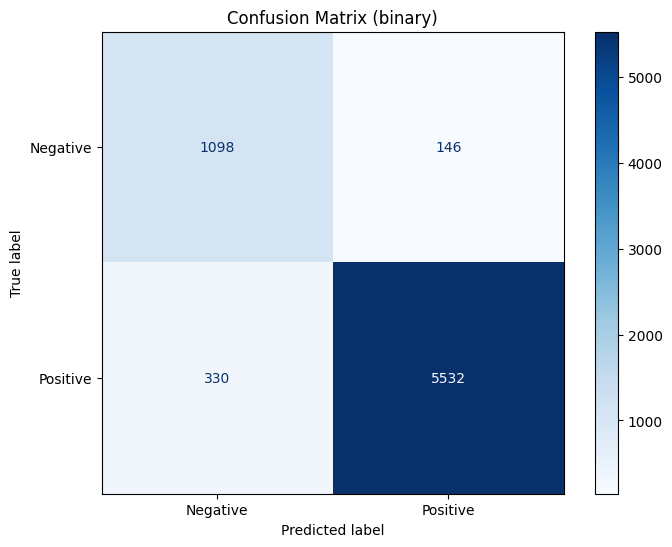

In [ ]:
import pandas as pd

val_csv   = 'validation_binary_preprocessed.csv'
df_val = pd.read_csv(val_csv)

val_texts = df_val['tweet_soft'].tolist()
val_labels = df_val['label'].values

results = pipeline_binary.evaluate(
    texts=val_texts,
    labels=val_labels
)

results = pipeline_multi.evaluate(
    texts=val_texts,
    labels=val_labels
)

# Gradio Interface Deployment
UI Features:
- Text input box with placeholder
- Primary "Analyze" and secondary "Clear" buttons
- Label output with emoji indicators
- Error handling for empty inputs

Deployment:
- Launches web interface with public URL
- Auto-enables sharing for Colab environments

Warning: Temporary link (1 week validity) with suggestion for permanent hosting



In [ ]:
import gradio as gr

def fun(text):
    if not text.strip():
        return "⛔ Please enter some text to analyze"

    try:
        prediction = pipeline_multi.predict(text)
        print(prediction)

        if isinstance(prediction, np.ndarray):
            prediction = int(prediction.item())
        elif hasattr(prediction, 'item'):
            prediction = prediction.item()

        label_mapping = {
            0: "👵 Age-related hate",
            1: "🌍 Ethnicity-based hate",
            2: "🚻 Gender-based hate",
            3: "✅ No hate detected",
            4: "🕍 Religion-based hate"
        }
        return label_mapping.get(int(prediction), "❓ Unknown result")

    except Exception as e:
        return f"🔧 Error during prediction: {str(e)}"

with gr.Blocks(theme=gr.themes.Soft(), title="Hate Speech Detector") as demo:
    gr.Markdown("""
    # 🛡️ Hate Speech Detector
    **Real-time analysis of text content**
    """)

    with gr.Row():
        input_text = gr.Textbox(
            lines=4,
            placeholder="Enter your text here...",
            label="Input Text",
            elem_id="input-box"
        )

        output_label = gr.Label(
            label="Analysis Result",
            elem_id="result-box",
            value="Awaiting input..."
        )

    with gr.Row():
        analyze_btn = gr.Button("Analyze", variant="primary")
        clear_btn = gr.Button("Clear")

    analyze_btn.click(
        fn=fun,
        inputs=input_text,
        outputs=output_label
    )

    clear_btn.click(
        fn=lambda: ("", "Awaiting input..."),
        inputs=None,
        outputs=[input_text, output_label]
    )

demo.launch()